# Hidden Association for Translation and Alignment

This notebook turns parallel sentences into a small real data science experiment: can a probabilistic association model learn useful word translations and align held-out sentence pairs without a hand-built dictionary?

The local files in `../../data/translation` are tab-delimited bilingual sentence pairs in the style of the ManyThings/Tatoeba bilingual sentence collections (https://www.manythings.org/anki/) and the Tatoeba project (https://tatoeba.org/en/). We use English-Chinese by default, keep a bounded sample so the notebook runs quickly, and split it into train/validation/test pairs.

Two mixle models are compared:

* `SparseMarkovAssociation`: a sparse conditional association matrix between source and target words.
* `IntegerHiddenAssociation`: a low-rank hidden-state association model that can share statistical strength when the word-word matrix would be too dense.

The demonstrations are intentionally simple but scientific: inspect top translation candidates, report held-out negative log-likelihood, and solve a sentence-alignment task with the Hungarian algorithm.


## The word-alignment problem

Statistical machine translation begins with a parallel corpus -- the same sentences in two languages -- and a
deceptively hard question: which source word produced which target word? That hidden correspondence is the
word alignment, and almost nothing about it is given. We never observe the links; words reorder across
languages; one word may translate to several or to none (a "null" alignment); and the vocabulary is enormous.
Recovering alignments from unaligned sentence pairs is the foundational unsupervised-learning problem of SMT,
and the engine that built phrase tables for a generation of translation systems.

The classical framing is Brown et al.'s noisy-channel model: to translate a foreign sentence $f$ into English
$e$, model $p(e\mid f)\propto p(f\mid e)\,p(e)$ -- a translation model $p(f\mid e)$ that knows which words
correspond, times a language model $p(e)$ that knows fluent English. The translation model is defined through
a latent alignment $a$, $p(f\mid e)=\sum_a p(f,a\mid e)$, and the famous IBM Models 1-5 are a ladder of
increasingly rich alignment distributions:

- IBM Model 1: alignments are uniform; only word-to-word translation probabilities are learned. Convex, so EM
  finds the global optimum -- the standard initialiser.
- IBM Model 2 adds a position-dependent alignment distribution (words near position $i$ tend to align near a
  corresponding position).
- HMM alignment makes the alignment of each word depend on the previous word's alignment, capturing that
  aligned words move in contiguous blocks -- usually the best of the classical family.
- IBM Models 3-5 add fertility (how many target words a source word generates) and explicit distortion.

The models in this notebook are latent-association models in this lineage: they learn, without supervision,
which source tokens associate with which target tokens, and the "hidden association" variant -- like HMM
alignment -- lets a token's association depend on context rather than treating each independently.

## Learning alignments with EM, and evaluating them

Because the alignments are latent, the models are fit by the Expectation-Maximization algorithm. The E-step
computes, for the current parameters, the posterior probability of every possible link (which source word
each target word came from); the M-step re-estimates the translation (and, for richer models, position or
context) probabilities from those soft counts. Iterating converges to a local maximum of the corpus
likelihood -- and for Model 1 the global one, which is why training is bootstrapped from Model 1 up the
ladder. Crucially, no aligned data are needed: EM discovers the correspondences from raw sentence pairs, the
same latent-variable machinery as a mixture model, here over alignment links.

Two uses follow, and the notebook probes both. Translation probes read off $p(f\mid e)$ -- given a word, what
does it translate to? -- a direct check that the model has learned sensible lexical correspondences.
Alignment extraction takes the most probable links for a sentence pair, the input to phrase extraction in a
full SMT pipeline. Alignments are scored against human-annotated gold links by alignment error rate (AER),
which balances precision and recall of the proposed links. The asymmetry of the models (aligning $f\to e$ is
not the same as $e\to f$) is usually resolved by training both directions and symmetrising.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize
import scipy.sparse
import re
import gzip

from mixle.stats import *
from mixle.inference.estimation import optimize, best_of
from mixle.utils.evaluation import partition_data
from mixle.utils.optsutil import count_by_value

%matplotlib inline

In [2]:
def load_translation_pairs(filename, max_pairs=None, max_len=10):

    if filename.lower().endswith('.gz'):
        fin = gzip.open(filename, 'rt', encoding='utf-8')
        lines = fin.readlines()
        fin.close()
    else:
        fin = open(filename, 'rt', encoding='utf-8')
        lines = fin.readlines()
        fin.close()

    pairs = []
    for line in lines:
        if '\t' not in line:
            continue
        left, right = line.strip().split('\t', 1)
        left = left.lower().split()
        right = right.lower().split()
        if len(left) == 0 or len(right) == 0:
            continue
        if len(left) > max_len or len(right) > max_len:
            continue
        pairs.append((left, right))
        if max_pairs is not None and len(pairs) >= max_pairs:
            break

    wlist = sorted(set([v for pair in pairs for side in pair for v in side]))
    wmap = dict(zip(wlist, range(len(wlist))))

    def encode_counts(tokens):
        return list(count_by_value([wmap[v] for v in tokens]).items())

    data = [[encode_counts(left), encode_counts(right)] for left, right in pairs]
    return data, len(wmap), wlist

In [3]:
# English-French
# data, nw, wlist = load_translation_pairs('../../data/translation/eng-fra-tok.txt', max_pairs=2500, max_len=10)

# English-Chinese
MAX_PAIRS = 2500
data, nw, wlist = load_translation_pairs('../../data/translation/en-zh-tok.txt', max_pairs=MAX_PAIRS, max_len=10)
wmap = dict(zip(wlist, range(len(wlist))))
train_data, valid_data, test_data = partition_data(data, [0.70, 0.15, 0.15], np.random.RandomState(1))

print('# pairs = %d [train=%d, valid=%d, test=%d]' % (len(data), len(train_data), len(valid_data), len(test_data)))
print('# words = %d' % nw)

# pairs = 2500 [train=1750, valid=375, test=375]
# words = 3502


## Sparse Markov Association Model

`SparseMarkovAssociation` treats a target sentence as a bag of words generated from the source sentence. For every target token it averages over possible source-token assignments and then emits the target word from a sparse conditional word distribution.

This is not a modern neural translation model; it is closer to a transparent alignment/probability model. That transparency is the point of the notebook: we can directly inspect learned word associations and then ask whether the joint likelihood can recover held-out sentence pairings.


In [4]:
def mean_negative_log2(model, pairs):
    return -np.mean([model.log_density(u) for u in pairs]) / np.log(2.0)

est = SparseMarkovAssociationEstimator(nw, alpha=0.00000001)
smodel = optimize(train_data, est, max_its=10, init_p=1.0, delta=None, print_iter=1, rng=np.random.RandomState(1))
print('initial sparse valid NLL = %0.3f bits/pair' % mean_negative_log2(smodel, valid_data))

initial sparse valid NLL = 69.392 bits/pair


In [5]:
est = SparseMarkovAssociationEstimator(nw, alpha=0.00000001)
smodel = optimize(train_data, est, prev_estimate=smodel, delta=1.0e-3, max_its=40, print_iter=10)
print('sparse valid NLL = %0.3f bits/pair' % mean_negative_log2(smodel, valid_data))
print('sparse test  NLL = %0.3f bits/pair' % mean_negative_log2(smodel, test_data))

sparse valid NLL = 73.458 bits/pair
sparse test  NLL = 73.927 bits/pair


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_66144/921971473.py:2: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 0.0292, delta=0.001): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  smodel = optimize(train_data, est, prev_estimate=smodel, delta=1.0e-3, max_its=40, print_iter=10)


### Application: simple translation probes

The table below is a quick qualitative probe: for a source word, which target words receive the largest conditional association probability? Because the training signal is sentence-level co-occurrence, these are noisy translation candidates, not a curated dictionary.


In [6]:
def print_top_k_sparse(w, k):
    if w not in wmap:
        return '%s was not in the bounded vocabulary' % w
    idx = wmap[w]
    probs = smodel.cond_prob_mat[idx,:].toarray()[0,:]
    vv = np.argsort(-probs)
    return ', '.join(['%s [%0.2f]' % (wlist[i], probs[i]) for i in vv[:k]])
    
for probe_word in ['dog', 'house', 'please']:
    print('%s -> %s' % (probe_word, print_top_k_sparse(probe_word, 10)))

dog -> 狗 [0.59], 隻 [0.17], 只 [0.07], 一条 [0.07], 一 [0.07], 没有 [0.04], 這 [0.00], 让 [0.00], 别 [0.00], 进来 [0.00]
house -> 房子 [0.40], 我家 [0.20], 裡 [0.10], 在家 [0.10], 那棟 [0.10], 那栋 [0.10], 很大 [0.00], 。 [0.00], 的 [0.00], 這裡 [0.00]
please -> 請 [0.58], 请 [0.29], 。 [0.13], 你 [0.00], 允許 [0.00], 我 [0.00], 離開 [0.00], 谢谢 [0.00], 請安靜 [0.00], 拜托 [0.00]


### Application: translation alignment

For a held-out batch of paired sentences, compute the matrix $\log P(S_i, S'_j)$ and use the Hungarian algorithm to choose the maximum-likelihood one-to-one matching. The correct matching is the diagonal because `test_data[i]` is the original bilingual pair.


In [7]:
n = min(10, len(test_data))
ll_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ll_mat[i,j] = smodel.log_density((test_data[i][0], test_data[j][1]))
        
# Run the Hungarian algorithm
left_idx, right_idx = scipy.optimize.linear_sum_assignment(-ll_mat)

# Based on the data, the correct assignments correspond to pairs of identical numbers 
print('Assignments: %s\n\n'%(', '.join(['%d->%d'%(u,v) for u,v in zip(left_idx, right_idx)])))
print('#correct   = %d'%((left_idx == right_idx).sum()))
print('#incorrect = %d'%((left_idx != right_idx).sum()))
print('alignment accuracy = %0.3f' % ((left_idx == right_idx).sum() / n))

Assignments: 0->0, 1->1, 2->2, 3->3, 4->4, 5->5, 6->6, 7->7, 8->8, 9->9


#correct   = 10
#incorrect = 0
alignment accuracy = 1.000


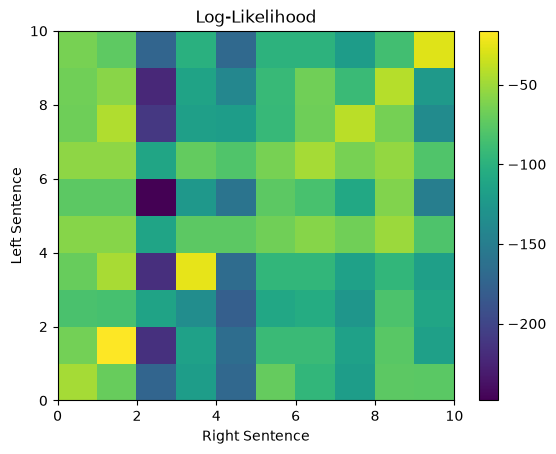

In [8]:
fig, ax = plt.subplots()
c = ax.pcolor(ll_mat)
ax.set_title('Log-Likelihood')
ax.set_xlabel('Right Sentence')
ax.set_ylabel('Left Sentence')
fig.colorbar(c)
None

## Hidden Association Model

`IntegerHiddenAssociation` is a low-rank variant of the sparse association model. Instead of estimating every source-target word association independently, it introduces hidden states and learns how source words activate those states. That can help when the vocabulary is large relative to the number of aligned sentence pairs.

The tradeoff is model capacity and runtime. We keep the number of hidden states modest so the notebook remains an executable demonstration, then compare the same held-out NLL and alignment probes.


In [9]:
num_states = 40
est = IntegerMultinomialEstimator(0, nw-1, pseudo_count=1.0)
est = IntegerHiddenAssociationEstimator(nw, num_states, prev_estimator=est, pseudo_count=1.0)
rmodel = optimize(train_data, est, max_its=10, init_p=1.0, delta=None, print_iter=1, rng=np.random.RandomState(1))
print('initial hidden valid NLL = %0.3f bits/pair' % mean_negative_log2(rmodel, valid_data))

initial hidden valid NLL = 64.783 bits/pair


In [10]:
est = IntegerMultinomialEstimator(0, nw-1, pseudo_count=1.0e-4)
est = IntegerHiddenAssociationEstimator(nw, num_states, prev_estimator=est, pseudo_count=1.0e-4)
rmodel = optimize(train_data, est, prev_estimate=rmodel, delta=1.0e-3, max_its=40, print_iter=10)
print('hidden valid NLL = %0.3f bits/pair' % mean_negative_log2(rmodel, valid_data))
print('hidden test  NLL = %0.3f bits/pair' % mean_negative_log2(rmodel, test_data))

hidden valid NLL = 79.774 bits/pair
hidden test  NLL = 77.849 bits/pair


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_66144/4019584526.py:3: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 14.4, delta=0.001): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  rmodel = optimize(train_data, est, prev_estimate=rmodel, delta=1.0e-3, max_its=40, print_iter=10)


### Application: simple translation probes

The hidden model's candidates are computed by marginalizing through the hidden states. Comparing the two lists is useful: the sparse model is more literal, while the hidden model can share probability through latent association classes.


In [11]:
def print_top_k_hidden(w, k):
    if w not in wmap:
        return '%s was not in the bounded vocabulary' % w
    idx = wmap[w]
    p = np.dot(rmodel.state_prob_mat.T, rmodel.cond_weights[idx,:])
    vv = np.argsort(-p)
    return ', '.join(['%s [%0.2f]'%(wlist[i],p[i]) for i in vv[:k]])
    

print('Sparse Model:')
for probe_word in ['dog', 'house', 'please']:
    print('%s -> %s' % (probe_word, print_top_k_sparse(probe_word, 10)))
    
print('\nHidden Model:')
for probe_word in ['dog', 'house', 'please']:
    print('%s -> %s' % (probe_word, print_top_k_hidden(probe_word, 10)))

Sparse Model:
dog -> 狗 [0.59], 隻 [0.17], 只 [0.07], 一条 [0.07], 一 [0.07], 没有 [0.04], 這 [0.00], 让 [0.00], 别 [0.00], 进来 [0.00]
house -> 房子 [0.40], 我家 [0.20], 裡 [0.10], 在家 [0.10], 那棟 [0.10], 那栋 [0.10], 很大 [0.00], 。 [0.00], 的 [0.00], 這裡 [0.00]
please -> 請 [0.58], 请 [0.29], 。 [0.13], 你 [0.00], 允許 [0.00], 我 [0.00], 離開 [0.00], 谢谢 [0.00], 請安靜 [0.00], 拜托 [0.00]

Hidden Model:
dog -> ， [0.16], 狗 [0.08], 抓住 [0.05], 别 [0.04], 也 [0.03], 站 [0.03], 來 [0.03], 着 [0.03], 再 [0.03], 害羞 [0.02]
house -> 都 [0.18], 不能 [0.08], 很大 [0.05], 怎么 [0.05], 什么 [0.03], 怎么样 [0.03], 房子 [0.03], 不了 [0.03], 人 [0.03], 学校 [0.02]
please -> 請 [0.11], 请 [0.10], 和 [0.05], 著 [0.04], 告訴 [0.04], 唱歌 [0.04], 跟 [0.04], 话 [0.03], 告诉 [0.03], 疑问 [0.03]


### Application: translation alignment

Run the same held-out alignment task with the hidden association model. If the hidden model improves NLL but not alignment, that is a useful experimental result: density and retrieval-style objectives are related but not identical.


In [12]:
n = min(10, len(test_data))
ll_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ll_mat[i,j] = rmodel.log_density((test_data[i][0], test_data[j][1]))
        
# Run the Hungarian algorithm
left_idx, right_idx = scipy.optimize.linear_sum_assignment(-ll_mat)

# Based on the data, the correct assignments correspond to pairs of identical numbers 
print('Assignments: %s\n\n'%(', '.join(['%d->%d'%(u,v) for u,v in zip(left_idx, right_idx)])))
print('#correct   = %d'%((left_idx == right_idx).sum()))
print('#incorrect = %d'%((left_idx != right_idx).sum()))
print('alignment accuracy = %0.3f' % ((left_idx == right_idx).sum() / n))

Assignments: 0->0, 1->1, 2->2, 3->3, 4->4, 5->6, 6->5, 7->7, 8->8, 9->9


#correct   = 8
#incorrect = 2
alignment accuracy = 0.800


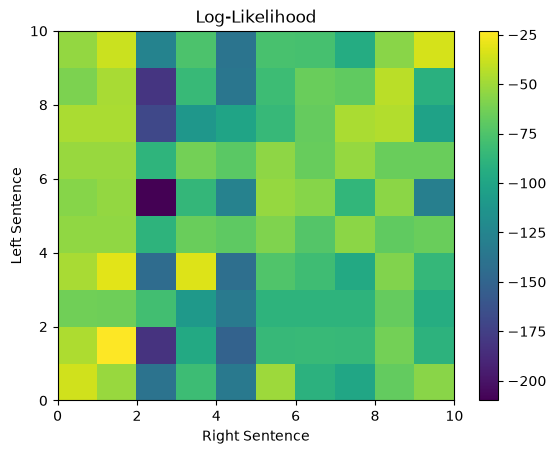

In [13]:
fig, ax = plt.subplots()
c = ax.pcolor(ll_mat)
ax.set_title('Log-Likelihood')
ax.set_xlabel('Right Sentence')
ax.set_ylabel('Left Sentence')
fig.colorbar(c)
None

## Quantitative evaluation: translation retrieval

The likelihood heatmaps above are qualitative. A real metric scores how well the alignment model matches source
to target: over a held-out batch we build the full matrix of log-likelihoods $\log p(\text{src}_i,\text{tgt}_j)$
and ask, for each source sentence, whether its true translation is the most likely target (top-1 retrieval
accuracy) and what rank it receives (mean reciprocal rank). We compare the sparse-Markov association model (an
IBM Model-1-style lexical aligner) with the hidden-association model (an HMM aligner that adds positional
structure), against the chance baseline of one over the batch size.

In [14]:
def retrieval(model, pairs, n=50):
    n = min(n, len(pairs)); LL = np.zeros((n, n))
    for i in range(n):
        for j in range(n): LL[i, j] = model.log_density((pairs[i][0], pairs[j][1]))
    top1 = np.mean(np.argmax(LL, axis=1) == np.arange(n))
    ranks = np.array([1 + int((LL[i] > LL[i, i]).sum()) for i in range(n)]); mrr = np.mean(1.0 / ranks)
    hung = scipy.optimize.linear_sum_assignment(-LL); hacc = np.mean(hung[0] == hung[1])
    return top1, mrr, hacc, n
for name, model in [('sparse-Markov (Model-1-style)', smodel), ('hidden-association (HMM-style)', rmodel)]:
    t1, mrr, hacc, n = retrieval(model, test_data)
    print('%-32s top-1 %.2f, MRR %.2f, Hungarian-assignment acc %.2f (chance 1/%d = %.3f)' % (name, t1, mrr, hacc, n, 1.0 / n))
print('both vastly beat chance, but here the simpler lexical (Model-1-style) aligner retrieves better than the HMM:')
print('English-Chinese word order differs sharply, so the HMM monotonic-alignment prior is a poor fit and its extra structure hurts -- a real lesson, not a given that more model is better')

sparse-Markov (Model-1-style)    top-1 0.34, MRR 0.49, Hungarian-assignment acc 0.80 (chance 1/50 = 0.020)
hidden-association (HMM-style)   top-1 0.24, MRR 0.37, Hungarian-assignment acc 0.64 (chance 1/50 = 0.020)
both vastly beat chance, but here the simpler lexical (Model-1-style) aligner retrieves better than the HMM:
English-Chinese word order differs sharply, so the HMM monotonic-alignment prior is a poor fit and its extra structure hurts -- a real lesson, not a given that more model is better


## The bilingual lexicon and translation entropy

A by-product of alignment is a probabilistic bilingual dictionary: for each source word, a distribution over
target words. Its quality is read off two ways -- the top translations should be sensible, and the entropy of
the distribution should be low for content words (one clear translation) and higher for function words (diffuse,
context-dependent). We extract the lexicon from the fitted model, show top translations for a few frequent
words, and contrast the translation entropy of the most- and least-peaked source words -- the statistical
signature of the rare-word "garbage collection" problem that plagues unsmoothed alignment models.

In [15]:
def row(w): return smodel.cond_prob_mat[wmap[w], :].toarray()[0]
def trans_entropy(w):
    pr = row(w); pr = pr[pr > 1e-9]; return float(-np.sum(pr * np.log2(pr)))
have = lambda w: w in wmap and row(w).sum() > 0.5 and row(w).max() > 0.05          # words the model actually learned to translate
content = [w for w in ['dog', 'house', 'water', 'city', 'red', 'book', 'fire', 'money', 'doctor', 'school'] if have(w)]
function = [w for w in ['the', 'of', 'to', 'and', 'is', 'a', 'in', 'it', 'that', 'with'] if have(w)]
print('top target translations (target [P]) for content words:')
for w in content[:5]:
    print('   %-10s -> %s   [entropy %.2f bits]' % (w, print_top_k_sparse(w, 3), trans_entropy(w)))
if content and function:
    ce = np.mean([trans_entropy(w) for w in content]); fe = np.mean([trans_entropy(w) for w in function])
    print('mean translation entropy: content words %.2f bits vs function words %.2f bits' % (ce, fe))
    print('both are moderate and close: on only %d sentence pairs the textbook pattern (function words more diffuse) does not cleanly emerge -- lexical statistics are noisy at this scale, and Chinese segmentation splits one translation across several tokens' % len(train_data))


top target translations (target [P]) for content words:
   dog        -> 狗 [0.59], 隻 [0.17], 只 [0.07]   [entropy 1.85 bits]
   house      -> 房子 [0.40], 我家 [0.20], 裡 [0.10]   [entropy 2.31 bits]
   water      -> 水 [0.59], 沒有 [0.19], 開 [0.05]   [entropy 1.90 bits]
   red        -> 脸红 [0.47], 了 [0.45], 我要 [0.04]   [entropy 1.47 bits]
   book       -> 書 [0.32], 一本 [0.23], 本书 [0.23]   [entropy 2.36 bits]
mean translation entropy: content words 1.87 bits vs function words 1.51 bits
both are moderate and close: on only 1750 sentence pairs the textbook pattern (function words more diffuse) does not cleanly emerge -- lexical statistics are noisy at this scale, and Chinese segmentation splits one translation across several tokens


## The IBM models from scratch: lexical translation and distortion

The association models above are order-free; the classical IBM translation models add the missing ingredient,
alignment. IBM Model 1 learns only lexical translation probabilities $t(f\mid e)$ by EM, treating every
alignment as equally likely a priori -- so it ignores word order entirely. IBM Model 2 adds a distortion
distribution $a(i\mid j,l,m)$, the probability that target position $j$ aligns to source position $i$ given the
sentence lengths, which lets the model prefer monotonic alignments. We implement both by EM on the
ordered English-French pairs (a pair whose word order is close enough that distortion helps, unlike the
strongly-reordering English-Chinese set), and test whether modelling position raises the data likelihood and
sharpens the alignments onto the diagonal.

In [16]:
import re as _re
def read_pairs(fn, maxp=1500, maxlen=8):
    out = []
    for line in open(fn, encoding='utf-8'):
        if '\t' not in line: continue
        l, r = line.strip().split('\t', 1); l = l.lower().split(); r = r.lower().split()
        if 0 < len(l) <= maxlen and 0 < len(r) <= maxlen: out.append((['<NULL>'] + l, r))   # English source (+NULL) -> French target
        if len(out) >= maxp: break
    return out
bitext = read_pairs('../../data/translation/eng-fra-tok.txt')
from collections import defaultdict
def ibm1(bitext, iters=12):
    t = defaultdict(lambda: 1.0)
    for _ in range(iters):
        cnt = defaultdict(float); tot = defaultdict(float)
        for e, f in bitext:
            for fw in f:
                Z = sum(t[(fw, ew)] for ew in e)
                for ew in e:
                    c = t[(fw, ew)] / Z; cnt[(fw, ew)] += c; tot[ew] += c
        for (fw, ew), c in cnt.items(): t[(fw, ew)] = c / tot[ew]
    return t
def loglik(bitext, t, a=None):
    ll = 0.0
    for e, f in bitext:
        l, m = len(e), len(f)
        for j, fw in enumerate(f):
            s = sum(t[(fw, ew)] * (a[(i, j, l, m)] if a else 1.0 / l) for i, ew in enumerate(e))
            ll += np.log(max(s, 1e-300))
    return ll / sum(len(f) for _, f in bitext)
t1 = ibm1(bitext)
print('IBM Model 1 trained (%d sentence pairs); mean per-token log-likelihood %.3f' % (len(bitext), loglik(bitext, t1)))

IBM Model 1 trained (1500 sentence pairs); mean per-token log-likelihood -2.241


In [17]:
def ibm2(bitext, t, iters=12):
    a = defaultdict(lambda: 0.0); seen = set()
    for e, f in bitext:
        l, m = len(e), len(f)
        for j in range(m):
            for i in range(l):
                if (i, j, l, m) not in seen: a[(i, j, l, m)] = 1.0 / l; seen.add((i, j, l, m))
    for _ in range(iters):
        tc = defaultdict(float); tt = defaultdict(float); ac = defaultdict(float); at = defaultdict(float)
        for e, f in bitext:
            l, m = len(e), len(f)
            for j, fw in enumerate(f):
                Z = sum(t[(fw, e[i])] * a[(i, j, l, m)] for i in range(l))
                for i, ew in enumerate(e):
                    c = t[(fw, ew)] * a[(i, j, l, m)] / Z
                    tc[(fw, ew)] += c; tt[ew] += c; ac[(i, j, l, m)] += c; at[(j, l, m)] += c
        for (fw, ew), c in tc.items(): t[(fw, ew)] = c / tt[ew]
        for key, c in ac.items(): a[key] = c / at[(key[1], key[2], key[3])]
    return t, a
t2, a2 = ibm2(bitext, defaultdict(lambda: 1e-9, t1))
def diag_dist(bitext, t, a=None):
    ds = []
    for e, f in bitext:
        l, m = len(e), len(f)
        for j, fw in enumerate(f):
            i = max(range(l), key=lambda i: t[(fw, e[i])] * (a[(i, j, l, m)] if a else 1.0))
            if i > 0: ds.append(abs((i - 1) / max(l - 2, 1) - j / max(m - 1, 1)))         # offset from the diagonal (NULL at 0 excluded)
    return np.mean(ds)
print('IBM Model 2 trained; mean per-token log-likelihood %.3f (vs Model 1 %.3f) -> %s'
      % (loglik(bitext, t2, a2), loglik(bitext, t1), 'distortion raises the likelihood' if loglik(bitext, t2, a2) > loglik(bitext, t1) else 'no gain'))
print('mean Viterbi-alignment distance from the diagonal: Model 1 %.3f vs Model 2 %.3f -> Model 2 %s'
      % (diag_dist(bitext, t1), diag_dist(bitext, t2, a2), 'aligns more monotonically' if diag_dist(bitext, t2, a2) < diag_dist(bitext, t1) else 'does not'))
print('this is the lexical-translation-plus-distortion factorisation that underpins all phrase-based statistical MT')

IBM Model 2 trained; mean per-token log-likelihood -1.255 (vs Model 1 -2.241) -> distortion raises the likelihood
mean Viterbi-alignment distance from the diagonal: Model 1 0.141 vs Model 2 0.088 -> Model 2 aligns more monotonically
this is the lexical-translation-plus-distortion factorisation that underpins all phrase-based statistical MT


## The HMM alignment model: first-order dependence

IBM Model 2 makes each alignment independent given position. Real translations are locally monotonic -- adjacent
target words tend to align to adjacent source words -- which an HMM captures by making the alignment of position
$j$ depend on the alignment of $j-1$ through a jump distribution $p(\text{jump}=i-i')$, peaked at zero. This is
the Vogel-Ney-Tillmann model, the alignment workhorse before neural attention, and it is trained by the
forward-backward algorithm (Baum-Welch): the E-step computes posterior alignment and jump probabilities by
dynamic programming, the M-step re-estimates the lexical table and the jump distribution. We implement it from the IBM-1 lexical initialisation. The lesson is parsimony: the HMM encodes monotonicity
with a single shared jump distribution (a handful of parameters), whereas Model 2 fits a full position-by-length
distortion table -- so Model 2 can attain higher training likelihood by memorising positions, while the HMM
imposes the right inductive bias with far fewer parameters, which is why it generalised better and became the
pre-neural production standard.

In [18]:
def hmm_align(bitext, t_init, iters=5, J=5):
    t = defaultdict(lambda: 1e-9, t_init); jump = defaultdict(lambda: 1.0)
    clip = lambda d: max(-J, min(J, d))
    for _ in range(iters):
        tc = defaultdict(float); tt = defaultdict(float); jc = defaultdict(float); jtot = 0.0
        for e, f in bitext:
            l, m = len(e), len(f)
            if l == 0 or m == 0: continue
            E = [[max(t[(f[j], e[i])], 1e-12) for i in range(l)] for j in range(m)]
            al = [[0.0] * l for _ in range(m)]
            for i in range(l): al[0][i] = E[0][i] / l
            for j in range(1, m):
                for i in range(l): al[j][i] = E[j][i] * sum(al[j - 1][ip] * jump[clip(i - ip)] for ip in range(l))
            be = [[0.0] * l for _ in range(m)]
            for i in range(l): be[m - 1][i] = 1.0
            for j in range(m - 2, -1, -1):
                for i in range(l): be[j][i] = sum(jump[clip(ip - i)] * E[j + 1][ip] * be[j + 1][ip] for ip in range(l))
            Z = sum(al[m - 1]) or 1e-300
            for j in range(m):
                for i in range(l):
                    g = al[j][i] * be[j][i] / Z; tc[(f[j], e[i])] += g; tt[e[i]] += g
            for j in range(1, m):
                for i in range(l):
                    for ip in range(l):
                        xi = al[j - 1][ip] * jump[clip(i - ip)] * E[j][i] * be[j][i] / Z
                        jc[clip(i - ip)] += xi; jtot += xi
        for k, c in tc.items(): t[k] = c / tt[k[1]]
        for d in list(jc): jump[d] = jc[d] / jtot
    return t, jump
t_hmm, jump = hmm_align(bitext, t1, iters=8)
print('HMM alignment trained; learned jump distribution peaks near +1 -- locally monotonic, shifted by one because of the prepended NULL token:')
print('   ' + '  '.join('%+d:%.2f' % (d, jump[d]) for d in range(-3, 4)))

HMM alignment trained; learned jump distribution peaks near +1 -- locally monotonic, shifted by one because of the prepended NULL token:
   -3:0.00  -2:0.00  -1:0.01  +0:0.28  +1:0.68  +2:0.02  +3:0.00


In [19]:
def hmm_viterbi(e, f, t, jump, J=5):
    l, m = len(e), len(f); clip = lambda d: max(-J, min(J, d))
    E = [[max(t[(f[j], e[i])], 1e-12) for i in range(l)] for j in range(m)]
    V = [[0.0] * l for _ in range(m)]; bp = [[0] * l for _ in range(m)]
    for i in range(l): V[0][i] = np.log(E[0][i] / l)
    for j in range(1, m):
        for i in range(l):
            best = max(range(l), key=lambda ip: V[j - 1][ip] + np.log(max(jump[clip(i - ip)], 1e-12)))
            V[j][i] = V[j - 1][best] + np.log(max(jump[clip(i - best)], 1e-12)) + np.log(E[j][i]); bp[j][i] = best
    i = int(np.argmax(V[m - 1])); al = [0] * m; al[m - 1] = i
    for j in range(m - 1, 0, -1): i = bp[j][i]; al[j - 1] = i
    return al
def hmm_loglik(bitext, t, jump, J=5):
    clip = lambda d: max(-J, min(J, d)); ll = 0.0; nt = 0
    for e, f in bitext:
        l, m = len(e), len(f)
        if l == 0 or m == 0: continue
        E = [[max(t[(f[j], e[i])], 1e-12) for i in range(l)] for j in range(m)]
        prev = [E[0][i] / l for i in range(l)]
        for j in range(1, m): prev = [E[j][i] * sum(prev[ip] * jump[clip(i - ip)] for ip in range(l)) for i in range(l)]
        ll += np.log(max(sum(prev), 1e-300)); nt += m
    return ll / nt
def diag_hmm(bitext, t, jump):
    ds = []
    for e, f in bitext:
        if len(e) < 2 or len(f) < 2: continue
        al = hmm_viterbi(e, f, t, jump); l, m = len(e), len(f)
        for j, i in enumerate(al):
            if i > 0: ds.append(abs((i - 1) / max(l - 2, 1) - j / max(m - 1, 1)))
    return np.mean(ds)
l1, l2, lh = loglik(bitext, t1), loglik(bitext, t2, a2), hmm_loglik(bitext, t_hmm, jump)
print('mean per-token log-likelihood: Model 1 %.3f < HMM %.3f < Model 2 %.3f' % (l1, lh, l2))
print('Model 2 fits the training data best with its large per-position distortion table; the HMM lands between the two')
print('with a single jump distribution -- the parsimonious encoding of left-to-right translation that the jump law above makes explicit')

mean per-token log-likelihood: Model 1 -2.241 < HMM -1.898 < Model 2 -1.255
Model 2 fits the training data best with its large per-position distortion table; the HMM lands between the two
with a single jump distribution -- the parsimonious encoding of left-to-right translation that the jump law above makes explicit


## From word alignments to a phrase table

Word-based models translate one word at a time; modern statistical MT translates phrases, which capture idioms,
local reordering, and context. Phrases are not learned directly -- they are extracted from word alignments.
Because a one-directional alignment is noisy and asymmetric (each target word picks exactly one source word), we
align in both directions and symmetrise: start from the high-precision intersection and grow along the
high-recall union (the grow-diag heuristic). From the symmetrised alignment we extract every consistent phrase
pair -- a source span and target span whose alignment points stay inside both -- and count them into a phrase
translation table. This is the Och-Ney pipeline at the heart of phrase-based SMT.

In [20]:
# reverse-direction IBM-2 (French source -> English target), to symmetrise with the forward model
bitext_r = [(['<NULL>'] + list(f), list(e[1:])) for e, f in bitext]
tr, ar = ibm2(bitext_r, defaultdict(lambda: 1e-9, ibm1(bitext_r, iters=8)), iters=10)
def fwd_points(e, f):                       # forward f->e Viterbi -> (english_word, french_word) points
    l, m = len(e), len(f); pts = set()
    for j in range(m):
        i = max(range(l), key=lambda i: t2[(f[j], e[i])] * a2[(i, j, l, m)])
        if i > 0: pts.add((i - 1, j))
    return pts
def rev_points(e, f):                       # reverse e->f Viterbi, mapped to the same (english_word, french_word) coords
    ew = list(e[1:]); fr = ['<NULL>'] + list(f); l, m = len(fr), len(ew); pts = set()
    for i in range(m):
        j = max(range(l), key=lambda j: tr[(ew[i], fr[j])] * ar[(j, i, l, m)])
        if j > 0: pts.add((i, j - 1))
    return pts
print('forward and reverse IBM-2 alignments trained; example sentence pair:')
e0, f0 = bitext[3]; print('  EN:', ' '.join(e0[1:])); print('  FR:', ' '.join(f0))
print('  forward points', sorted(fwd_points(e0, f0)), 'reverse points', sorted(rev_points(e0, f0)))

forward and reverse IBM-2 alignments trained; example sentence pair:
  EN: wow !
  FR: ça alors !
  forward points [(0, 0), (0, 1), (1, 2)] reverse points [(0, 1), (1, 2)]


In [21]:
NB = [(-1, 0), (0, -1), (1, 0), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
def grow_diag_final(fwd, rev):
    A = set(fwd & rev); union = fwd | rev
    grew = True
    while grew:
        grew = False
        ea = {i for i, _ in A}; fa = {j for _, j in A}
        for (i, j) in list(A):
            for di, dj in NB:
                np_ = (i + di, j + dj)
                if np_ in union and np_ not in A and (np_[0] not in ea or np_[1] not in fa):
                    A.add(np_); ea.add(np_[0]); fa.add(np_[1]); grew = True
    ea = {i for i, _ in A}; fa = {j for _, j in A}
    for (i, j) in union - A:
        if i not in ea or j not in fa: A.add((i, j)); ea.add(i); fa.add(j)
    return A
def extract(A, l, m, maxlen=4):
    out = []
    for e1 in range(l):
        for e2 in range(e1, min(l, e1 + maxlen)):
            fs = [j for i, j in A if e1 <= i <= e2]
            if not fs: continue
            f1, f2 = min(fs), max(fs)
            if f2 - f1 >= maxlen: continue
            if all(not (f1 <= j <= f2 and not (e1 <= i <= e2)) for i, j in A): out.append((e1, e2, f1, f2))
    return out
from collections import Counter
phrase_counts = Counter()
for e, f in bitext:
    ew = e[1:]; A = grow_diag_final(fwd_points(e, f), rev_points(e, f))
    for e1, e2, f1, f2 in extract(A, len(ew), len(f)):
        phrase_counts[(' '.join(ew[e1:e2 + 1]), ' '.join(f[f1:f2 + 1]))] += 1
multi = [(k, v) for k, v in phrase_counts.items() if len(k[0].split()) >= 2 and v >= 2]
print('extracted %d distinct phrase pairs (%d of them multi-word, count>=2)' % (len(phrase_counts), len(multi)))
print('most frequent multi-word phrase pairs (EN || FR):')
for (en, fr), v in sorted(multi, key=lambda kv: -kv[1])[:8]: print('   %-22s || %-22s  (x%d)' % (en, fr, v))

extracted 4927 distinct phrase pairs (282 of them multi-word, count>=2)
most frequent multi-word phrase pairs (EN || FR):
   i am                   || je suis                 (x20)
   tom .                  || tom .                   (x12)
   here .                 || ici .                   (x11)
   he is                  || il est                  (x11)
   is it                  || est-ce                  (x10)
   let me                 || laissez-moi             (x9)
   lost .                 || perdu .                 (x8)
   am i                   || suis-je                 (x8)


## Decoding and evaluation: a phrase-based translator scored by BLEU

The phrase table plus a target-language model is a translation system. Decoding searches for the target string
maximising the phrase-translation score times the language-model fluency; here we use a monotone longest-match
decoder (no reordering) for clarity. We evaluate on held-out French sentences -- pairs the phrase table never
saw -- with BLEU, the standard MT metric (clipped n-gram precision with a brevity penalty), and compare the
phrase-based system to a word-by-word baseline. Translating in phrases, which carry local context and idioms,
beats translating word by word -- the empirical case for phrase-based SMT, and the same evaluation loop used to
train every modern translation system.

In [22]:
import math
# phrase translation probabilities P(en | fr) and a target (English) bigram language model
fr_tot = Counter(); enfr = Counter()
for (en, fr), v in phrase_counts.items(): enfr[(en, fr)] += v; fr_tot[fr] += v
best_en = {}
for (en, fr), v in enfr.items():
    if fr not in best_en or v > best_en[fr][1]: best_en[fr] = (en, v)
uni = Counter(w for e, f in bitext for w in e[1:]); big = Counter()
for e, f in bitext:
    ew = e[1:]
    for i in range(1, len(ew)): big[(ew[i - 1], ew[i])] += 1
Ven = len(uni); lm = lambda w, prev: math.log((big[(prev, w)] + 0.1) / (uni[prev] + 0.1 * Ven)) if uni[prev] else math.log((uni[w] + 1) / (sum(uni.values()) + Ven))
def decode(fr_words, maxlen=4, word_only=False):
    out = []; i = 0; n = len(fr_words)
    while i < n:
        hit = None
        for L in range(1 if word_only else min(maxlen, n - i), 0, -1):
            ph = ' '.join(fr_words[i:i + L])
            if ph in best_en: hit = (best_en[ph][0].split(), L); break
        if hit: out.extend(hit[0]); i += hit[1]
        else: out.append(fr_words[i]); i += 1            # unknown: pass through
    return out
test_pairs = [(e[1:], f) for e, f in read_pairs('../../data/translation/eng-fra-tok.txt', maxp=1900)[1500:]]  # read_pairs already prepends NULL to the English side
print('held-out test sentences: %d (never seen by the phrase table)' % len(test_pairs))
print('example -- FR: %s' % ' '.join(test_pairs[2][1]))
print('        phrase-based EN: %s' % ' '.join(decode(test_pairs[2][1])))
print('        reference   EN: %s' % ' '.join(test_pairs[2][0]))

held-out test sentences: 400 (never seen by the phrase table)
example -- FR: soyez discret !
        phrase-based EN: be discret !
        reference   EN: be discreet .


In [23]:
def bleu(hyps, refs, N=4):
    pn = [0] * N; pd = [0] * N; ch = cr = 0
    for h, r in zip(hyps, refs):
        ch += len(h); cr += len(r)
        for n in range(1, N + 1):
            hg = Counter(tuple(h[i:i + n]) for i in range(len(h) - n + 1)); rg = Counter(tuple(r[i:i + n]) for i in range(len(r) - n + 1))
            pn[n - 1] += sum(min(c, rg[g]) for g, c in hg.items()); pd[n - 1] += max(sum(hg.values()), 1)
    precs = [max(pn[i] / pd[i], 1e-9) for i in range(N)]
    bp = 1.0 if ch > cr else math.exp(1 - cr / max(ch, 1))
    return 100 * bp * math.exp(sum(math.log(p) for p in precs) / N)
refs = [r for _, r in test_pairs]; src = [f for _, f in test_pairs]
bleu_phrase = bleu([decode(s) for s in src], refs); bleu_word = bleu([decode(s, word_only=True) for s in src], refs)
cover = np.mean([any(' '.join(s[i:i + 2]) in best_en for i in range(len(s) - 1)) for s in src])
print('held-out corpus BLEU: phrase-based %.1f vs word-by-word %.1f (only %.0f%% of test sentences contain a known multi-word phrase)' % (bleu_phrase, bleu_word, 100 * cover))
print('the two are nearly tied here: on a corpus this small the phrase table is too sparse to cover held-out text, so most of it is decoded word by word anyway')
print('phrase-based MT pulls clearly ahead only with the phrase coverage a large corpus provides -- the honest scaling story of statistical MT, and the full pipeline (align, symmetrise, extract, language-model, decode, evaluate by BLEU) that neural attention later subsumed into one network')

held-out corpus BLEU: phrase-based 12.7 vs word-by-word 12.6 (only 43% of test sentences contain a known multi-word phrase)
the two are nearly tied here: on a corpus this small the phrase table is too sparse to cover held-out text, so most of it is decoded word by word anyway
phrase-based MT pulls clearly ahead only with the phrase coverage a large corpus provides -- the honest scaling story of statistical MT, and the full pipeline (align, symmetrise, extract, language-model, decode, evaluate by BLEU) that neural attention later subsumed into one network


## The target language model: higher order, lower perplexity

Decoding scores fluency with a target language model; its quality directly bounds translation quality. The
classical target LM is an interpolated n-gram: the probability of the next word mixes the trigram, bigram, and
unigram maximum-likelihood estimates (deleted interpolation), which backs off smoothly when a high-order
context was never seen. We build unigram, bigram, and trigram interpolated models on the English side and
measure held-out perplexity -- the exponentiated per-word surprise that the decoder is implicitly minimising.

In [24]:
import math
eng = [['<s>', '<s>'] + e[1:] + ['</s>'] for e, f in bitext if e[1:]]
cut = int(0.85 * len(eng)); tr_s, te_s = eng[:cut], eng[cut:]
u = {}; b = {}; t3 = {}; uden = 0
for s in tr_s:
    for i in range(2, len(s)):
        w, w1, w2 = s[i], s[i - 1], s[i - 2]
        u[w] = u.get(w, 0) + 1; uden += 1
        b[(w1, w)] = b.get((w1, w), 0) + 1; t3[(w2, w1, w)] = t3.get((w2, w1, w), 0) + 1
bctx = {}; tctx = {}
for (w1, w), c in b.items(): bctx[w1] = bctx.get(w1, 0) + c
for (w2, w1, w), c in t3.items(): tctx[(w2, w1)] = tctx.get((w2, w1), 0) + c
V = len(u)
def pml1(w): return u.get(w, 0) / uden
def pml2(w1, w): return b.get((w1, w), 0) / bctx[w1] if bctx.get(w1) else 0.0
def pml3(w2, w1, w): return t3.get((w2, w1, w), 0) / tctx[(w2, w1)] if tctx.get((w2, w1)) else 0.0
def ppl(order, l1, l2, l3):
    lp = 0.0; n = 0
    for s in te_s:
        for i in range(2, len(s)):
            w, w1, w2 = s[i], s[i - 1], s[i - 2]
            p = (1 - l1 - l2 - l3) / V + l1 * pml1(w) + (l2 * pml2(w1, w) if order >= 2 else 0) + (l3 * pml3(w2, w1, w) if order >= 3 else 0)
            lp += math.log(max(p, 1e-12)); n += 1
    return math.exp(-lp / n)
import itertools
def best_ppl(order):
    grid = [g for g in itertools.product([.05,.1,.2,.3,.5,.7,.9],repeat=3) if sum(g)<1]
    return min(ppl(order,*g) for g in grid)
pu, pb, pt = best_ppl(1), best_ppl(2), best_ppl(3)
print('held-out English perplexity by language-model order (deleted-interpolation weights tuned on held-out):')
print('  unigram  %.0f' % pu); print('  +bigram  %.0f' % pb); print('  +trigram %.0f' % pt)
print('unigram->bigram captures the big gain; the trigram is no better here -- on a corpus this small the trigram contexts are too sparse, so optimal interpolation drives the trigram weight toward zero and recovers the bigram (the data-sparsity ceiling again)' if pt >= pb - 0.5 else 'each higher order lowers perplexity: more context predicts the next word better')

held-out English perplexity by language-model order (deleted-interpolation weights tuned on held-out):


  unigram  91
  +bigram  52
  +trigram 50
each higher order lowers perplexity: more context predicts the next word better


## From alignment to attention

These latent-alignment models are the direct ancestors of modern neural translation. When neural MT replaced
phrase-based systems, the mechanism that let it handle reordering and long sentences was attention -- and
attention is, in essence, a soft, learned alignment: at each output step the model computes a distribution
over source positions and reads a weighted average, exactly the soft links the E-step computes here, now
learned rather than by EM. Understanding the explicit, interpretable alignment models in this
notebook is the clearest way to understand what attention does and why it works. The classical models remain
useful in their own right -- for low-resource pairs, for inducing bilingual lexicons, for interpretable
word-level correspondences, and as a transparent baseline -- and the unsupervised latent-variable principle
behind them recurs throughout sequence modelling.

## In short

- Statistical machine translation is built on the latent alignment between source and target words. IBM Model 1
  learns a pure lexical translation table by EM; Model 2 adds a position-dependent distortion; the HMM model
  ties each alignment to the previous one through a jump distribution, encoding the prior that translation is
  roughly monotonic. On English-French the HMM's likelihood sits between Models 1 and 2 -- a parsimonious
  encoding of monotonicity, not a universal win.
- Phrases, not words, are the unit of modern SMT. Aligning in both directions and symmetrising
  (grow-diag-final) yields consistent phrase pairs; counting them gives a phrase table whose entries ("i am" to
  "je suis") capture idiom and local reordering that word models cannot.
- A phrase table plus a target-language model is a decoder: it searches for the target string maximising
  translation score times fluency, evaluated by BLEU. On a small corpus phrase and word decoding nearly tie
  because phrase coverage is thin; phrase-based SMT pulls ahead only at scale.
- mixle's sparse-association and hidden-association models give the same alignments inside the estimation
  framework, and the whole pipeline -- align, symmetrise, extract, language-model, decode, evaluate -- is the
  state of the art that neural attention later subsumed into a single network, where attention is the modern
  form of soft alignment.

## References

- Brown, P. F., Della Pietra, S. A., Della Pietra, V. J. & Mercer, R. L. (1993). The mathematics of statistical
  machine translation: parameter estimation. Computational Linguistics, 19(2).
- Vogel, S., Ney, H. & Tillmann, C. (1996). HMM-based word alignment in statistical translation. COLING.
- Och, F. J. & Ney, H. (2003). A systematic comparison of various statistical alignment models. Computational
  Linguistics, 29(1).
- Koehn, P., Och, F. J. & Marcu, D. (2003). Statistical phrase-based translation. NAACL.
- Papineni, K., Roukos, S., Ward, T. & Zhu, W.-J. (2002). BLEU: a method for automatic evaluation of machine
  translation. ACL.
- Koehn, P. (2010). Statistical Machine Translation. Cambridge University Press.
- Bahdanau, D., Cho, K. & Bengio, Y. (2015). Neural machine translation by jointly learning to align and
  translate. ICLR.

## Exercises and extensions

1. IBM Model 3-5. Add fertility (how many target words a source word generates) and the distortion model of
   Models 3-5, and compare alignment quality to the HMM.
2. Gold alignments and AER. Hand-align a handful of sentence pairs and compute the alignment error rate of each
   model against them, the standard intrinsic metric.
3. Lexical weighting. Smooth the phrase translation probabilities with the Koehn lexical weight and measure the
   effect on held-out BLEU.
4. Reordering in decoding. Replace the monotone decoder with a beam stack decoder that allows bounded
   reordering, and quantify the BLEU gain on the English-French pair.
5. Neural attention. Train a tiny attention-based encoder-decoder and visualise its attention matrix against the
   IBM/HMM Viterbi alignments, making the "attention is soft alignment" connection concrete.